Text(0.5, 0.5, 'Y')

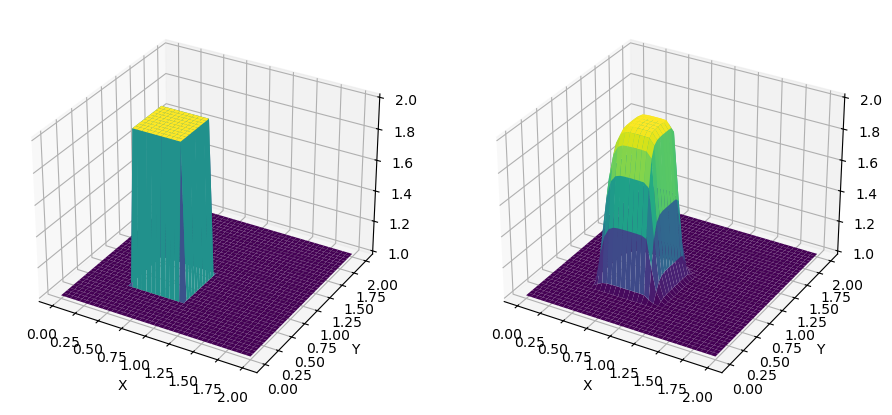

In [8]:
import numpy
from matplotlib import pyplot, cm
from mpl_toolkits.mplot3d import Axes3D

###variable declarations 变量声明

nx = 41
ny = 41
nt = 120
c = 1
dx = 2 / (nx -1)
dy = 2 / (ny -1)
sigma = 0.0009
nu = 0.01
dt = sigma * dx * dy / nu

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 2, ny)

u = numpy.ones((ny, nx))        # 数组 u[y, x]：行 = y 坐标，列 = x 坐标
v = numpy.ones((ny, nx))
un = numpy.ones((ny, nx))       # 横向：x 方向，列索引：0, 1, 2, ..., nx-2, nx-1
vn = numpy.ones((ny, nx))       # 纵向：y 方向，行索引：0, 1, 2, ..., ny-2, ny-1
comb = numpy.ones((ny, nx))

###Assign initial conditions 设定初始条件

u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # [10:21, 10:21] = 2
v[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2

fig = pyplot.figure(figsize=(11,7), dpi=100)
ax1 = fig.add_subplot(121, projection='3d')
X, Y = numpy.meshgrid(x, y)
ax1.plot_surface(X, Y, u, cmap=cm.viridis)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')

for n in range(nt + 1):
    un = u.copy()
    vn = v.copy()

    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     dt / dx * un[1:-1, 1:-1] * 
                     (un[1:-1, 1:-1] - un[1:-1, 0:-2]) - 
                     dt / dy * vn[1:-1, 1:-1] * 
                     (un[1:-1, 1:-1] - un[0:-2, 1:-1]) + 
                     nu * dt / dx**2 * 
                     (un[1:-1,2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) + 
                     nu * dt / dy**2 * 
                     (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1]))
    
    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] - 
                     dt / dx * un[1:-1, 1:-1] *
                     (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                     dt / dy * vn[1:-1, 1:-1] * 
                    (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) + 
                     nu * dt / dx**2 * 
                     (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) +
                     nu * dt / dy**2 *
                     (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1]))
     
    u[0, :] = 1             # 在二维数值计算中：
    u[-1, :] = 1            # 数组第一个维度 [行, ] → 代表 y 方向（竖直方向）
    u[:, 0] = 1             # 数组第二个维度 [ , 列] → 代表 x 方向（水平方向）
    u[:, -1] = 1            # 0 = 最边缘起点，-1 = 最边缘终点
    
    v[0, :] = 1   # 下
    v[-1, :] = 1  # 上
    v[:, 0] = 1   # 左
    v[:, -1] = 1  # 右

ax2 = fig.add_subplot(122, projection='3d')

X, Y = numpy.meshgrid(x, y)
ax2.plot_surface(X, Y, u, cmap=cm.viridis)

ax2.set_xlabel('X')
ax2.set_ylabel('Y')